In [1]:
import pandas as pd
import os
from IPython.display import display

# Olist Brazilian E-Commerce — Exploratory Data Analysis

**Author:** Zakee Ul Hassan
**Dataset:** [Olist on Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
**Goal:** Answer 4 business questions about late deliveries, reviews, regional differences, and cancellations.

---

## 1. Setup & Data Loading

In [2]:
data_path = "../data"
files = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translations": "product_category_name_translation.csv",
}

In [35]:

dfs = {}

for name, file in files.items():
    df = pd.read_csv(os.path.join(data_path, file))  
    dfs[name] = df   
    print(f"{name} loaded successfully")

orders loaded successfully
order_items loaded successfully
customers loaded successfully
products loaded successfully
sellers loaded successfully
payments loaded successfully
reviews loaded successfully
geolocation loaded successfully
category_translations loaded successfully


## 2. Initial Data Exploration

Quick peek at each table — shape, sample rows, and column types — before any analysis.

In [36]:
print(len(dfs))
print(dfs.keys())

9
dict_keys(['orders', 'order_items', 'customers', 'products', 'sellers', 'payments', 'reviews', 'geolocation', 'category_translations'])


In [37]:
for name, df in dfs.items():
    print(f"--- {name} ---")
    display(df.head())
    df.info()

--- orders ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
--- order_items ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
--- customers ---


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
--- geolocation ---


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB
--- category_translations ---


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


### Initial Observations

- **9 tables, all linked through IDs** — orders is the central table. Customers join via `customer_id`; items, payments, reviews join via `order_id`; products join via `product_id`; sellers join via `seller_id`.
- **Date columns are stored as text** (`object` dtype) — need conversion with `pd.to_datetime()` before any time-based analysis.
- **Some tables have more rows than orders** — `items` and `payments` have multiple rows per order (one order = multiple items, possibly split payments).
- **Missing values exist** in delivery date columns — likely correspond to cancelled or undelivered orders.
- **Categories are in Portuguese** — will need to merge with `category_translation` to get English names for plotting.

---

## 3. Merging Tables Into a Master Dataframe

Olist data is split across 9 tables. To answer real business questions, we need to join them on shared IDs.

In [38]:
orders = dfs['orders']
customers = dfs['customers']
items = dfs['order_items']
payments = dfs['payments']
reviews = dfs['reviews']
products = dfs['products']
sellers = dfs['sellers']
category_translation = dfs['category_translations']

In [39]:
# Step 1: orders + customers (linked by customer_id)
master = orders.merge(customers, on='customer_id', how='left')
# Step 2: + items (linked by order_id)
master = master.merge(items, on='order_id', how='left')
# Step 3: + reviews (linked by order_id)
master = master.merge(reviews, on='order_id', how='left')
# Step 4: + payments (linked by order_id)
master = master.merge(payments, on='order_id', how='left')
# Step 5: + products (linked by product_id)
master = master.merge(products, on='product_id', how='left')
# Step 6: + sellers (linked by seller_id)
master = master.merge(sellers, on='seller_id', how='left')
# Step 7: + category_translation (linked by product_category_name)
master = master.merge(category_translation, on='product_category_name', how='left')
print("Master dataframe shape:", master.shape)
print("Number of unique orders:", master['order_id'].nunique())
print("\nColumns:", master.columns.tolist())

Master dataframe shape: (119143, 40)
Number of unique orders: 99441

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name_english']


In [40]:
# Convert all date columns from text to actual datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp',
    'shipping_limit_date'
]

In [43]:
for col in date_cols:
    if col in master.columns:
        master[col] = pd.to_datetime(master[col], errors='coerce')

# Add useful derived columns
master['delivery_days'] = (
    master['order_delivered_customer_date'] - master['order_purchase_timestamp']
).dt.days

master['was_late'] = (
    master['order_delivered_customer_date'] > master['order_estimated_delivery_date']
)

master['purchase_year'] = master['order_purchase_timestamp'].dt.year
master['purchase_month'] = master['order_purchase_timestamp'].dt.month
master['purchase_day_of_week'] = master['order_purchase_timestamp'].dt.day_name()
master['purchase_hour'] = master['order_purchase_timestamp'].dt.hour

print("Date conversion done ✓")
print("\nDelivery days summary:")
print(master['delivery_days'].describe())
print(f"\n% of orders delivered late: {master['was_late'].mean()}%")
print(f"\n% of orders delivered late: {master['was_late'].mean() * 100:.1f}%")

Date conversion done ✓

Delivery days summary:
count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

% of orders delivered late: 0.07611022049134233%

% of orders delivered late: 7.6%


In [44]:

os.makedirs('../data', exist_ok=True)

master.to_csv('../data/master_cleaned.csv', index=False)

print(f"Saved master_cleaned.csv — {master.shape[0]:,} rows × {master.shape[1]} columns")

Saved master_cleaned.csv — 119,143 rows × 46 columns


---

## 4. Business Question 1: What Drives Late Deliveries?

Already established: **7.6% of orders arrive late.** Now we dig in — *who* is more likely to receive a late delivery?

We'll look at:
- Late delivery rate by customer state
- Late delivery rate by product category

In [45]:
# Calculate late delivery rate per state
# Use unique orders only (not the inflated master rows from items/payments)
orders_clean = master.drop_duplicates(subset='order_id')

late_by_state = (
    orders_clean.groupby('customer_state')['was_late']
    .mean()
    .sort_values(ascending=False) * 100
)

print("Top 5 states by late delivery rate:")
print(late_by_state.head(5).round(1))
print("\nBottom 5 states (best on-time performance):")
print(late_by_state.tail(5).round(1))

Top 5 states by late delivery rate:
customer_state
AL    23.0
MA    18.9
PI    15.4
CE    14.7
SE    14.6
Name: was_late, dtype: float64

Bottom 5 states (best on-time performance):
customer_state
PR    4.9
AP    4.4
AM    4.1
AC    3.7
RO    2.8
Name: was_late, dtype: float64


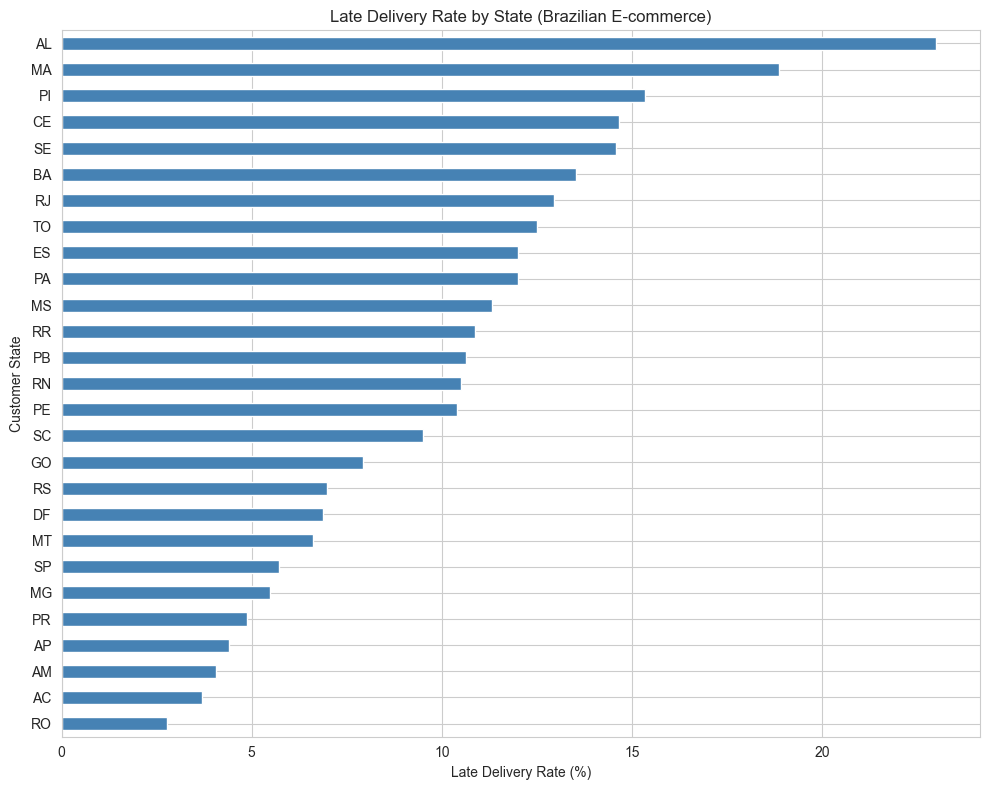

In [46]:
plt.figure(figsize=(10, 8))
late_by_state.plot(kind='barh', color='steelblue')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Customer State')
plt.title('Late Delivery Rate by State (Brazilian E-commerce)')
plt.gca().invert_yaxis()  # so highest rate appears at top
plt.tight_layout()
plt.savefig('../late_delivery_by_state.png', dpi=100, bbox_inches='tight')
plt.show()

### Findings — Question 1

- **Late delivery rate ranges from 2.8% (Rondônia) to 23.0% (Alagoas)** — an 8x difference between best and worst states.
- **Northeast states dominate the worst performers:** AL, MA, PI, CE, SE all exceed 14% late delivery.
- **Counterintuitively, remote North states (AP, AM, AC, RO) have *low* late rates** despite their distance. This likely reflects more generous *estimated* delivery dates for these regions, not faster actual logistics — late is defined relative to the estimate, not absolute time.
- **Implication:** Late-delivery problems are concentrated in the Northeast, suggesting either logistics capacity issues in that region or estimates that don't match local reality.

> *Note: Used `drop_duplicates(subset='order_id')` to ensure each order counts once when computing rates — otherwise orders with multiple items would be over-weighted.*

---
## 5. Business Question 2: Best & Worst Review Categories

We'll find which product categories make customers happiest (and angriest), filtering out tiny-sample categories where averages can't be trusted.

In [47]:
category_reviews = master.groupby('product_category_name_english').agg(
    average_review_score=('review_score', 'mean'),
    review_count=('review_score', 'count')
)
category_reviews = category_reviews[category_reviews['review_count'] >= 30]
category_reviews.sort_values('average_review_score', ascending=True).head(10)

,average_review_score,review_count
product_category_name_english,,
diapers_and_hygiene,3.256410,39
office_furniture,3.526791,1773
fashion_male_clothing,3.548611,144
fixed_telephony,3.672862,269
fashio_female_clothing,3.780000,50
furniture_mattress_and_upholstery,3.804878,41
audio,3.840849,377
furniture_bedroom,3.841270,126
party_supplies,3.847826,46


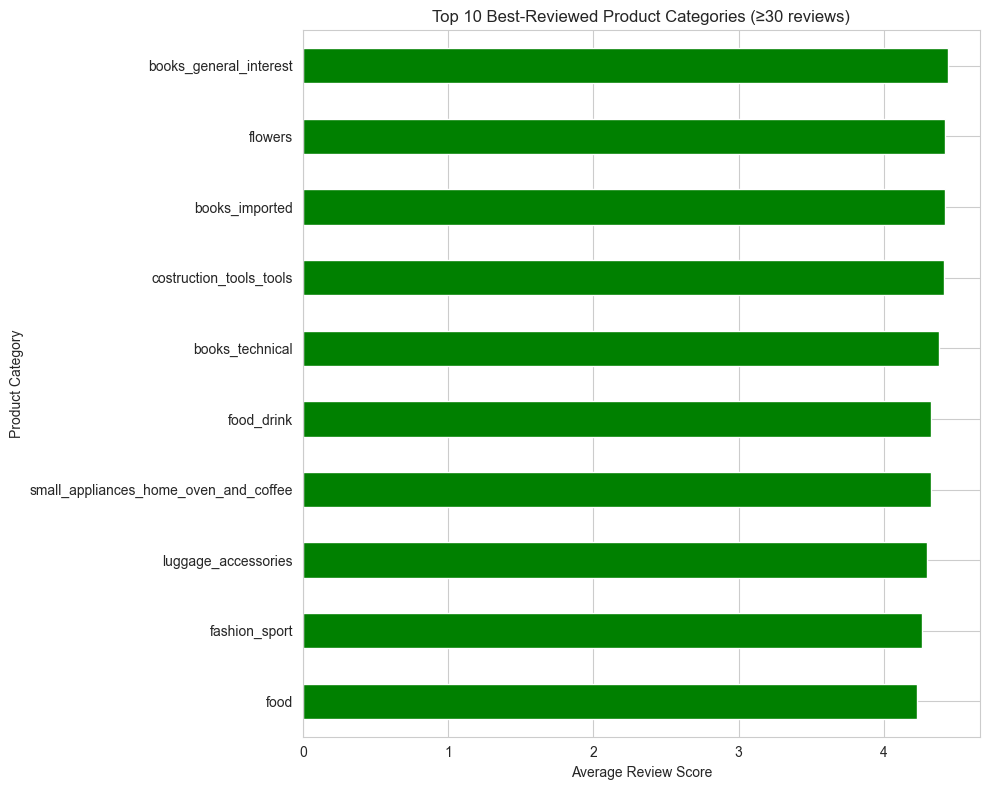

In [48]:
plt.figure(figsize=(10, 8))
category_reviews.sort_values('average_review_score', ascending=False).head(10)['average_review_score'].plot(
    kind='barh', color='green'
)
plt.xlabel('Average Review Score')
plt.ylabel('Product Category')
plt.title('Top 10 Best-Reviewed Product Categories (≥30 reviews)')
plt.gca().invert_yaxis()  # so highest rate appears at top
plt.tight_layout()
plt.savefig('../avg_best_review_scores.png', dpi=100, bbox_inches='tight')
plt.show()

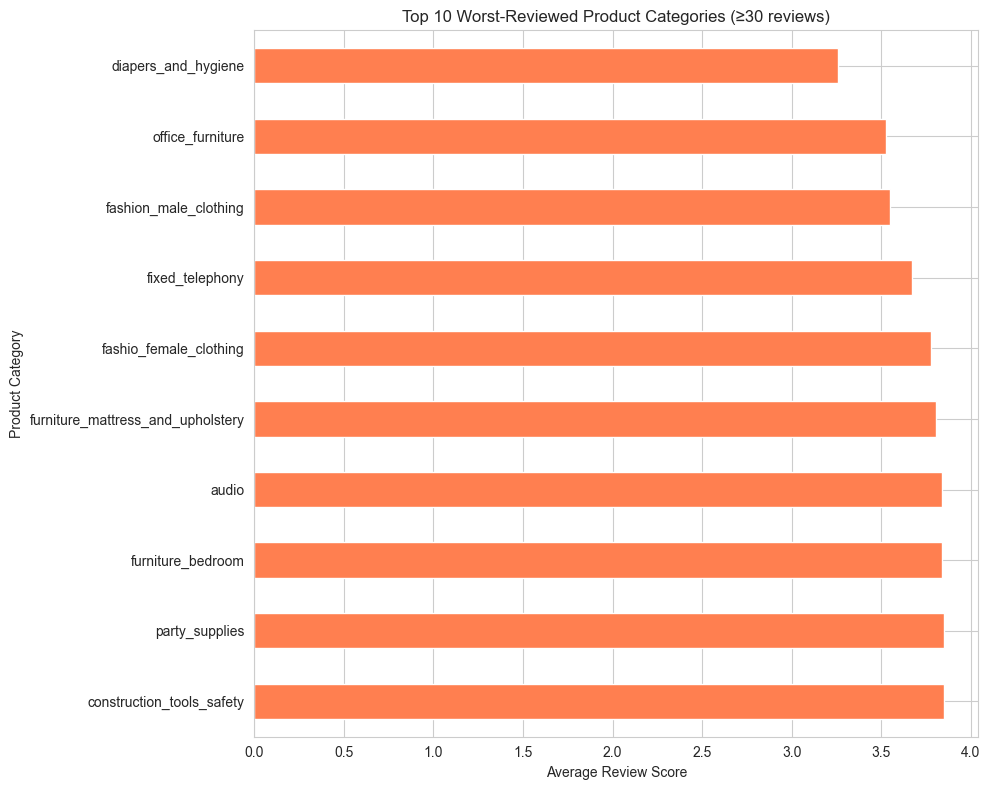

In [49]:
plt.figure(figsize=(10, 8))
category_reviews.sort_values('average_review_score', ascending=True).head(10)['average_review_score'].plot(
    kind='barh', color='coral'
)
plt.xlabel('Average Review Score')
plt.ylabel('Product Category')
plt.title('Top 10 Worst-Reviewed Product Categories (≥30 reviews)')
plt.gca().invert_yaxis()  # so highest rate appears at top
plt.tight_layout()
plt.savefig('../avg_worst_review_scores.png', dpi=100, bbox_inches='tight')
plt.show()

### Findings — Question 2

After filtering for categories with ≥30 reviews (to avoid small-sample noise), the spread between best and worst categories is **3.25 to 4.44** — about a 1.2-point gap on a 5-point scale.

**Top performers cluster around predictable, standardized items:**
- Books dominate (general, imported, technical) — three of the top five
- Flowers, food, food_drink, luggage_accessories also rank highly
- **Pattern:** Customers know what they're getting. No sizing, no assembly, no surprises.

**Worst performers cluster around items where reality often disappoints expectation:**
- `diapers_and_hygiene` (3.25) — likely linked to delivery delays for essentials
- Furniture categories (office, mattress, bedroom) — assembly issues, damage in transit, room-fit problems
- Fashion clothing (male and female) — universal sizing complaints
- `audio` — high technical expectations

**Implication for Olist:** Review problems aren't random — they're concentrated in categories where size, fit, assembly, or condition matters most. Targeted interventions (better size guides, assembly support, packaging upgrades) by category could lift average scores more than blanket policies.

> *Note: One typo in the source data — `fashio_female_clothing` is missing an "n". Kept as-is to match the original dataset.*

Q3: Are there regional differences in order value or delivery time across Brazil?

In [50]:
orders_clean.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'product_category_name_english',
 'delivery_days',
 'was_late',
 'purchase_year',
 'purchase_month',
 'purchase_day_of_week',
 'purchase_hour']

In [51]:
regional_diff = orders_clean.groupby('customer_state').agg(
    n_orders=('order_id', 'nunique'),
    avg_order_value=('price', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    late_delivery_rate=('was_late', 'mean')
)

# Convert late rate to percentage
regional_diff['late_delivery_rate'] = regional_diff['late_delivery_rate'] * 100

# Filter to states with enough orders to be statistically reliable
regional_diff = regional_diff[regional_diff['n_orders'] >= 100]

# Sort by slowest delivery first
regional_diff = regional_diff.sort_values('avg_delivery_days', ascending=False)

# Inspect both ends
print("Slowest 15 states:")
print(regional_diff.head(15).round(2))

Slowest 15 states:
                n_orders  avg_order_value  avg_delivery_days  \
customer_state                                                 
AM                   148           141.38              25.99   
AL                   413           185.13              24.04   
PA                   975           172.73              23.32   
MA                   747           151.13              21.12   
SE                   350           157.13              21.03   
CE                  1336           157.05              20.82   
PB                   536           201.56              19.95   
PI                   495           161.00              18.99   
RO                   253           178.50              18.91   
BA                  3380           138.31              18.87   
RN                   485           164.60              18.82   
PE                  1652           150.13              17.97   
MT                   907           152.97              17.59   
TO                   

In [52]:
print("\nFastest 5 states:")
print(regional_diff.tail(5).round(2))


Fastest 5 states:
                n_orders  avg_order_value  avg_delivery_days  \
customer_state                                                 
SC                  3637           131.66              14.48   
DF                  2140           131.19              12.51   
MG                 11635           126.27              11.54   
PR                  5045           123.88              11.53   
SP                 41746           114.72               8.30   

                late_delivery_rate  
customer_state                      
SC                            9.51  
DF                            6.87  
MG                            5.48  
PR                            4.88  
SP                            5.72  


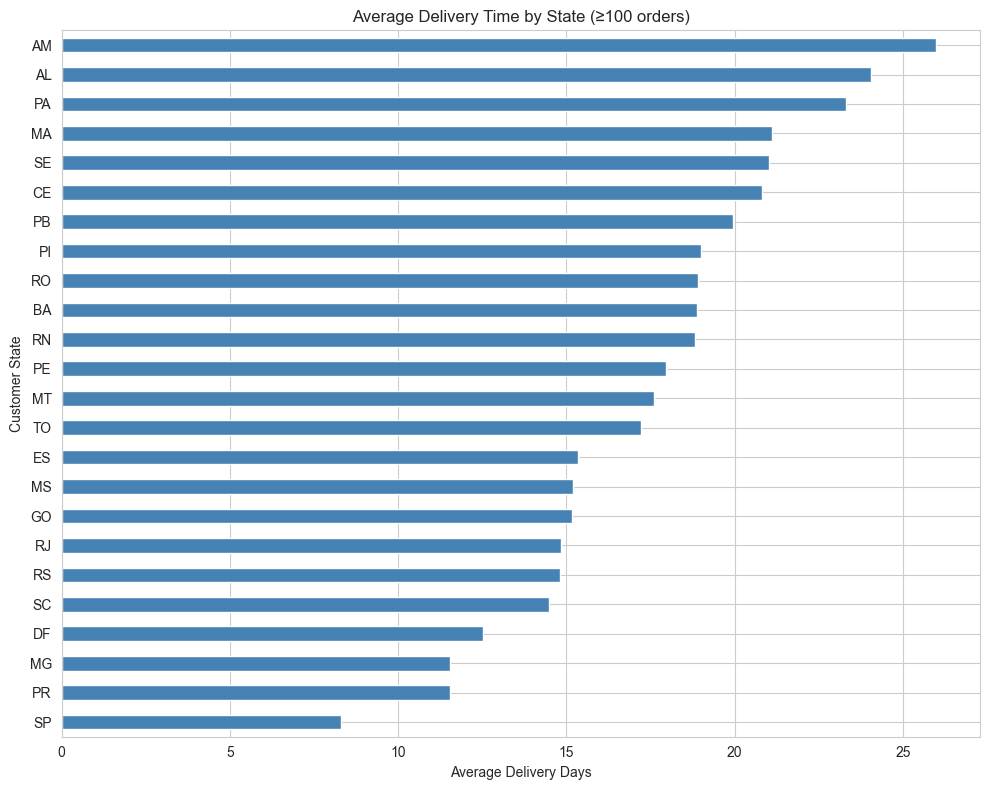

In [53]:
plt.figure(figsize=(10, 8))
regional_diff['avg_delivery_days'].plot(kind='barh', color='steelblue')
plt.xlabel('Average Delivery Days')
plt.ylabel('Customer State')
plt.title('Average Delivery Time by State (≥100 orders)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../avg_delivery_days_by_state.png', dpi=100, bbox_inches='tight')
plt.show()

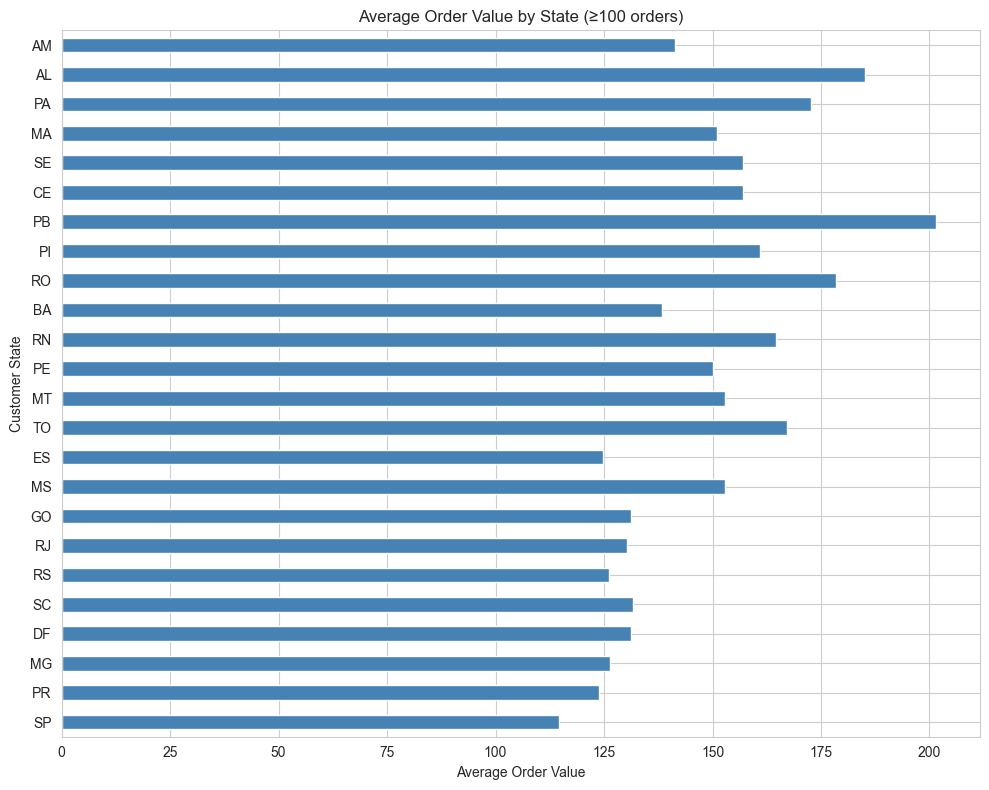

In [54]:
plt.figure(figsize=(10, 8))
regional_diff['avg_order_value'].plot(kind='barh', color='steelblue')
plt.xlabel('Average Order Value')
plt.ylabel('Customer State')
plt.title('Average Order Value by State (≥100 orders)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../avg_order_value_by_state.png', dpi=100, bbox_inches='tight')
plt.show()

### Findings — Question 3

After filtering to states with ≥100 orders, four clear patterns emerge:

**1. The Q1 "padded estimates" hypothesis is confirmed.**
Amazonas (AM) and Alagoas (AL) take roughly the same time to deliver
(~25 days), but Alagoas is marked late 5.7× more often (23% vs 4%).
This is direct evidence that delivery estimates for remote Northern
states are padded — the absolute speed is similar, but expectations
absorb the difference. Rondônia (RO) shows the same pattern: 19 days
average delivery, 2.8% late rate.

**2. São Paulo dominates volume by a wide margin.**
SP alone accounts for ~42% of all orders (41,746 of ~99,400), and the
southern triangle of SP + MG + PR represents ~58% of total volume.
SP also has the fastest delivery time (8.3 days), reflecting that most
Olist sellers are based there.

**3. The Northeast has a genuine logistics problem.**
States like AL, MA, SE, CE, PI, BA, PE cluster in the slowest 15 *and*
have high late rates (10-23%). Unlike the remote North, their padded
estimates aren't generous enough to absorb the slow delivery — they
fail on both metrics simultaneously.

**4. Order values vary inversely with volume.**
SP has the lowest average order value (R$ 114.72) despite the highest
volume. Smaller, more remote states like PB, AL, and RO show order
values 50-75% higher (R$ 178-201). Plausible explanation: remote
shoppers hesitate on small online purchases due to shipping cost and
delay, concentrating demand on higher-ticket items.

> *Note: `avg_order_value` here uses the first item's price per order
> (due to dedup). A more rigorous version would aggregate item prices
> per order before deduping.*

 Q4 — When Do Customers Cancel?
The business question: When do customers cancel orders, and is there a pattern?

In [55]:
orders_clean['is_canceled'] = (orders_clean['order_status'] == 'canceled').astype(int)

# Quick sanity check — what % of all orders get canceled?
overall_cancel_rate = orders_clean['is_canceled'].mean() * 100
print(f"Overall cancellation rate: {overall_cancel_rate:.2f}%")

Overall cancellation rate: 0.63%


C:\Users\NEXGEN\AppData\Local\Temp\ipykernel_21904\1988399304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_clean['is_canceled'] = (orders_clean['order_status'] == 'canceled').astype(int)


In [56]:
cancel_by_dow = orders_clean.groupby('purchase_day_of_week')['is_canceled'].mean() * 100

# Reorder days properly (default is alphabetical: Friday first, Wednesday last — gross)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cancel_by_dow = cancel_by_dow.reindex(day_order)

print("Cancellation rate by day of week (%):")
print(cancel_by_dow.round(2))

Cancellation rate by day of week (%):
purchase_day_of_week
Monday       0.71
Tuesday      0.70
Wednesday    0.62
Thursday     0.68
Friday       0.51
Saturday     0.57
Sunday       0.57
Name: is_canceled, dtype: float64


In [57]:
cancel_by_month = orders_clean.groupby('purchase_month')['is_canceled'].mean() * 100
print("Cancellation rate by month (%):")
print(cancel_by_month.round(2))

Cancellation rate by month (%):
purchase_month
1     0.46
2     1.06
3     0.60
4     0.35
5     0.50
6     0.36
7     0.67
8     1.02
9     0.86
10    1.09
11    0.49
12    0.19
Name: is_canceled, dtype: float64


In [58]:
cancel_by_hour = orders_clean.groupby('purchase_hour')['is_canceled'].mean() * 100
print("Cancellation rate by hour of day (%):")
print(cancel_by_hour.round(2))

Cancellation rate by hour of day (%):
purchase_hour
0     0.71
1     0.77
2     0.39
3     0.74
4     0.00
5     1.06
6     1.39
7     0.57
8     0.54
9     0.71
10    0.76
11    0.64
12    0.67
13    0.61
14    0.62
15    0.68
16    0.61
17    0.62
18    0.62
19    0.60
20    0.61
21    0.55
22    0.62
23    0.39
Name: is_canceled, dtype: float64


In [59]:
cancel_by_payment = orders_clean.groupby('payment_type').agg(
    cancel_rate=('is_canceled', 'mean'),
    n_orders=('order_id', 'count')
)
cancel_by_payment['cancel_rate'] = cancel_by_payment['cancel_rate'] * 100

# Filter out tiny payment types
cancel_by_payment = cancel_by_payment[cancel_by_payment['n_orders'] >= 100]
cancel_by_payment = cancel_by_payment.sort_values('cancel_rate', ascending=False)

print("Cancellation rate by payment type:")
print(cancel_by_payment.round(2))

Cancellation rate by payment type:
              cancel_rate  n_orders
payment_type                       
voucher              3.21      2739
credit_card          0.57     75387
boleto               0.48     19784
debit_card           0.46      1527


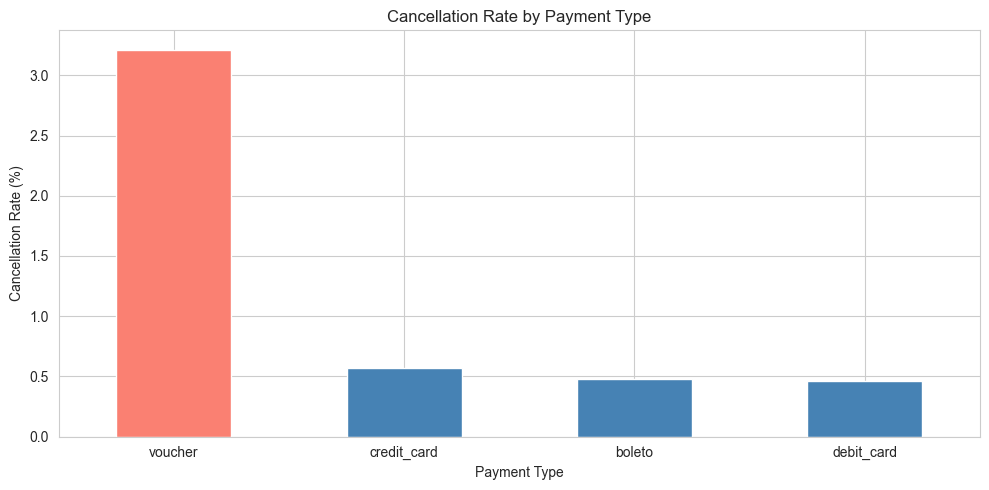

In [60]:
plt.figure(figsize=(10, 5))
cancel_by_payment['cancel_rate'].plot(kind='bar', color=['salmon', 'steelblue', 'steelblue', 'steelblue'])
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Payment Type')
plt.title('Cancellation Rate by Payment Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../cancel_rate_by_payment.png', dpi=100, bbox_inches='tight')
plt.show()

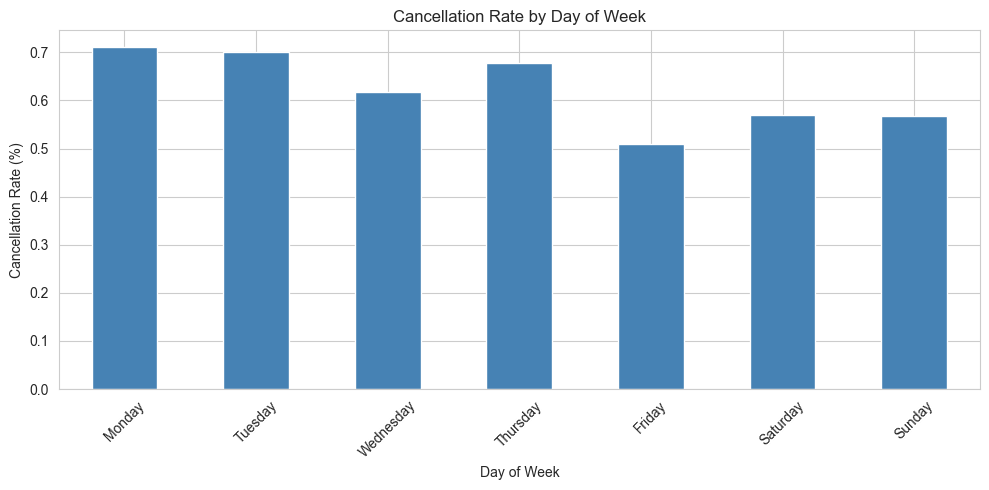

In [61]:
plt.figure(figsize=(10, 5))
cancel_by_dow.plot(kind='bar', color='steelblue')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Day of Week')
plt.title('Cancellation Rate by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../cancel_rate_by_dow.png', dpi=100, bbox_inches='tight')
plt.show()

### Findings — Question 4: Cancellation Patterns

**Overall baseline: 0.63% of orders canceled.** Notably lower than typical
e-commerce industry rates (2-5%), suggesting Olist's "canceled" status
is narrowly defined (likely excludes "unavailable" or undelivered orders
that functionally are cancellations).

**Headline finding: Voucher payments cancel ~6× more than other methods.**
| Payment type | Cancel rate | Volume |
|---|---|---|
| Voucher | 3.21% | 2,739 |
| Credit card | 0.57% | 75,387 |
| Boleto | 0.48% | 19,784 |
| Debit card | 0.46% | 1,527 |

Plausible explanations: voucher application failures at checkout (value
mismatch, expired vouchers), promotional impulse leading to second
thoughts, or stricter fraud screening. **Actionable next step:** Olist
should investigate voucher checkout flows for failure points.

**Weaker patterns (likely noise or single-year artifacts):**
- *Day of week:* slight early-week vs late-week tilt (Mon 0.71% → Fri 0.51%),
  but the 0.20pp absolute spread is small enough to potentially be noise.
- *Month:* Aug-Oct cluster slightly higher (~1%), Apr/Jun/Dec lower (~0.3%).
  Could reflect Black-Friday-season volume effects, but with only one year
  of data this is suggestive at best.
- *Hour of day:* Apparent spike at 4-6 AM is likely a small-sample artifact
  (few orders are placed in early-morning hours).

**Limitations:**
- "Canceled" status excludes other functional cancellations (unavailable,
  undelivered, etc.)
- Day-of-week reflects when the order was *placed*, not cancelled — a
  fuller analysis would measure the gap between purchase and cancellation
- Single year of data limits confidence on monthly seasonality


---

## Conclusions

This analysis surfaced four findings, ranked by strength:

1. **Voucher payments are a clear outlier in cancellation rate** (6× the baseline) — the strongest signal in the dataset and a concrete place for Olist to investigate.
2. **The Northeast region has a real logistics problem** — slow *and* late, unlike the remote North, which is slow but on-time.
3. **Review scores cluster by product type** — predictable items (books, flowers) score highly; items where size/fit/condition matters (furniture, fashion) lag.
4. **Late delivery is a relative metric, not an absolute one** — "late" means relative to estimate, and Olist's estimates absorb distance for remote regions.

### What I'd do next with more time
- Sum item prices per order (rather than first-item dedup) for a more rigorous order-value analysis
- Look at seller-level performance (do specific sellers drive most of the late deliveries?)
- Use multiple years of data to confirm or reject the monthly cancellation pattern
- Investigate voucher checkout flows for failure modes